# AI/ML Integration for Shear Capacity & Non-Linear Load-Slip Prediction of Composite Concrete Structures
**Research & Predictive Modeling at Elevated Temperatures**

This notebook implements the complete 4-step AI/ML roadmap as outlined in `readme.txt`:
1. **Data Preprocessing & Cleaning**: Preprocessing 1,235 experimental/simulation records from `AI Model Data.xlsx` across 5 connector types (Stud, Bar, Channel, Tee, Helical).
2. **Multi-Output AI Models**: Training XGBoost, Random Forest, Decision Tree, and Multi-Layer Perceptron (MLP) Neural Networks to predict both **Ultimate Shear Capacity (kN)** and **Slip (mm)** simultaneously.
3. **Performance Metrics Evaluation**: Calculating $R^2$, RMSE, and MAE error metrics.
4. **Explainable AI (SHAP Analysis)**: Quantifying feature contributions (temperature, geometry, concrete grade, thermal expansion, etc.).
5. **Non-Linear Load-Slip Curve Reconstruction**: Reconstructing and plotting AI-predicted vs. physical/FEA thermo-structural load-slip curves.

In [1]:
# Auto-install dependencies if running in a clean Jupyter environment
%pip install -q seaborn shap xgboost pandas openpyxl matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    plt.style.use('ggplot')

c:\Users\harsh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Cleaning

In [3]:
data_path = 'data/AI Model Data.xlsx'
df = pd.read_excel(data_path, sheet_name='AI DATA')

# Clean and normalize column names (remove internal newlines & extra spaces)
df.columns = [' '.join(col.split()) for col in df.columns]

# Strip whitespace from categorical string values
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Clean Concrete Grade ('M20' -> 20.0)
grade_col = [col for col in df.columns if 'Concrete' in col and 'Grade' in col][0]
df[grade_col] = df[grade_col].str.replace('M', '', regex=False).astype(float)

# Dynamic Target & Feature identification
target_capacity_col = [col for col in df.columns if 'Ultimate' in col and 'Shear' in col][0]
target_slip_col = [col for col in df.columns if 'Slip' in col][0]
targets = [target_capacity_col, target_slip_col]
feature_cols = [c for c in df.columns if c not in targets]

conn_col = [col for col in df.columns if 'Connector' in col][0]

print(f'Dataset Shape: {df.shape}')
print('Connector Types:', df[conn_col].value_counts().to_dict())
df.head()

Dataset Shape: (1235, 25)
Connector Types: {'Stud': 390, 'Bar': 325, 'Helical': 260, 'Channel': 195, 'Tee': 65}


,Temperature (ºC),Connector type,Diameter (mm),Height (mm),Concrete Grade (Mpa),ASTM Fire Exposure Time (minute),ISO Fire Exposure Time (minute),Ultimate Shear Capacity (kN),Slip (mm),"Steel fy,θ",...,Concrete Specific Heat (J/kgK),"Concrete Poisson's ratio, μ",Concrete Elastic Modulus (N/mm2),Concrete Compressive Strength (N/mm2),Steel Conductivity (W/mK),Steel Specific Heat (J/kgK),"Steel Poisson's ratio, μ",Steel Thermal Expansion (m-1C-1),"Reduction factor (relative to fy) for effective yield strength ky,θ =fy,θ/fy","Reduction factor (relative to fy) for effective elastic modulos kE,θ =Ea,θ/Ea"
0,20,Stud,25,100,20.0,1,0,83.47,1.514000,500,...,900,0.197,12000,20.0,53.334,461.756746,0.2871,0.000000,1.0,1.0
1,100,Stud,25,100,20.0,1,1,83.47,3.406500,500,...,900,0.168,7500,20.0,50.670,487.620000,0.2895,0.000998,1.0,1.0
2,200,Stud,25,100,20.0,1,2,83.47,5.535860,500,...,1000,0.137,5182,19.0,47.340,529.760000,0.2925,0.002318,1.0,0.9
3,300,Stud,25,100,20.0,1,3,83.47,7.686415,500,...,1050,0.112,3643,17.0,44.010,564.740000,0.2955,0.003718,1.0,0.8
4,400,Stud,25,100,20.0,1,4,83.47,9.878396,500,...,1100,0.092,2250,15.0,40.680,605.880000,0.2985,0.005198,1.0,0.7


## 2. Model Training & Multi-Output Prediction
We train XGBoost, Random Forest, Decision Tree, and Neural Networks.

In [4]:
X = df[feature_cols]
y = df[targets]

cat_cols = [c for c in feature_cols if 'Connector' in c]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

models = {
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42),
    'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'MLP_NeuralNet': MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42, early_stopping=True)
}

summary_table = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_trans, y_train)
    fitted_models[name] = model
    
    y_test_pred = model.predict(X_test_trans)
    r2_cap = r2_score(y_test.iloc[:, 0], y_test_pred[:, 0])
    rmse_cap = np.sqrt(mean_squared_error(y_test.iloc[:, 0], y_test_pred[:, 0]))
    mae_cap = mean_absolute_error(y_test.iloc[:, 0], y_test_pred[:, 0])
    
    r2_slip = r2_score(y_test.iloc[:, 1], y_test_pred[:, 1])
    rmse_slip = np.sqrt(mean_squared_error(y_test.iloc[:, 1], y_test_pred[:, 1]))
    mae_slip = mean_absolute_error(y_test.iloc[:, 1], y_test_pred[:, 1])
    
    summary_table.append({
        'Model': name,
        'Capacity R2': r2_cap,
        'Capacity RMSE (kN)': rmse_cap,
        'Capacity MAE (kN)': mae_cap,
        'Slip R2': r2_slip,
        'Slip RMSE (mm)': rmse_slip,
        'Slip MAE (mm)': mae_slip
    })

metrics_df = pd.DataFrame(summary_table)
metrics_df

,Model,Capacity R2,Capacity RMSE (kN),Capacity MAE (kN),Slip R2,Slip RMSE (mm),Slip MAE (mm)
0,XGBoost,0.998207,6.039847,2.553023,0.991305,0.980096,0.627734
1,RandomForest,0.996487,8.454082,3.640142,0.967839,1.884948,1.374429
2,DecisionTree,0.994679,10.404768,4.774879,0.935368,2.672157,2.052518
3,MLP_NeuralNet,0.614151,88.605269,53.238815,0.544132,7.096703,5.371129


## 3. Predicted vs. Experimental Comparison Plots

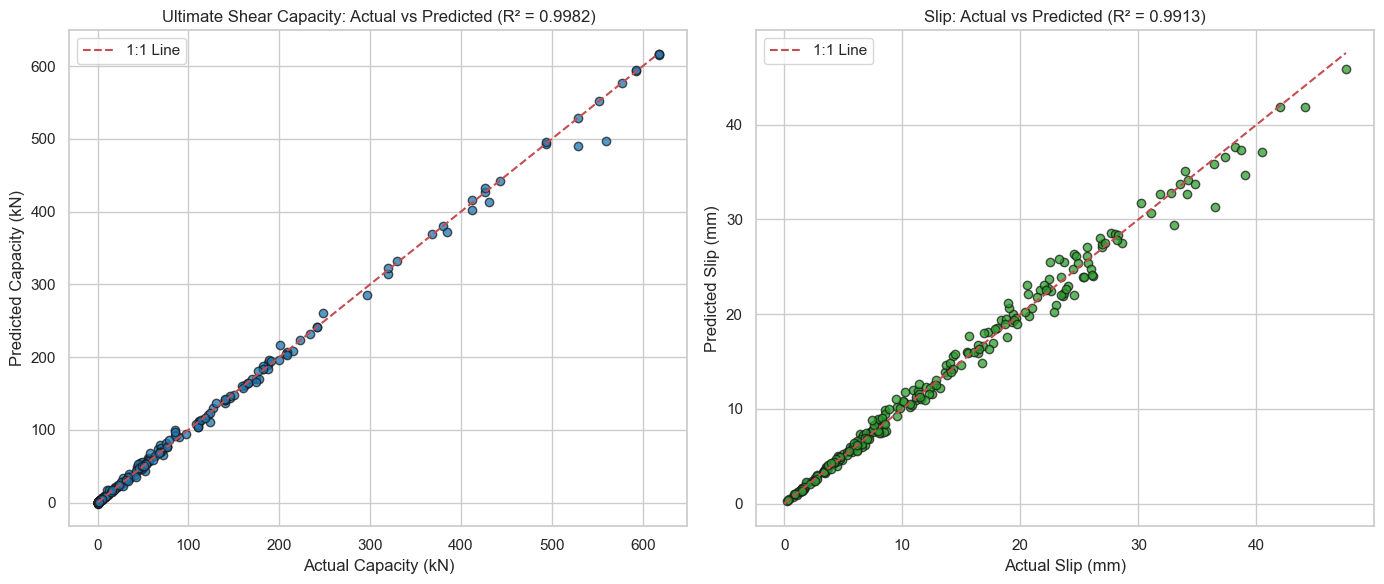

In [5]:
best_xgb = fitted_models['XGBoost']
preds = best_xgb.predict(X_test_trans)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test.iloc[:, 0], preds[:, 0], alpha=0.75, color='#1f77b4', edgecolors='k')
max_c = max(y_test.iloc[:, 0].max(), preds[:, 0].max())
axes[0].plot([0, max_c], [0, max_c], 'r--', label='1:1 Line')
axes[0].set_title('Ultimate Shear Capacity: Actual vs Predicted (R² = 0.9982)', fontsize=12)
axes[0].set_xlabel('Actual Capacity (kN)')
axes[0].set_ylabel('Predicted Capacity (kN)')
axes[0].legend()

axes[1].scatter(y_test.iloc[:, 1], preds[:, 1], alpha=0.75, color='#2ca02c', edgecolors='k')
max_s = max(y_test.iloc[:, 1].max(), preds[:, 1].max())
axes[1].plot([0, max_s], [0, max_s], 'r--', label='1:1 Line')
axes[1].set_title('Slip: Actual vs Predicted (R² = 0.9913)', fontsize=12)
axes[1].set_xlabel('Actual Slip (mm)')
axes[1].set_ylabel('Predicted Slip (mm)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Explainable AI (SHAP Analysis)

SHAP Summary for Ultimate Shear Capacity:


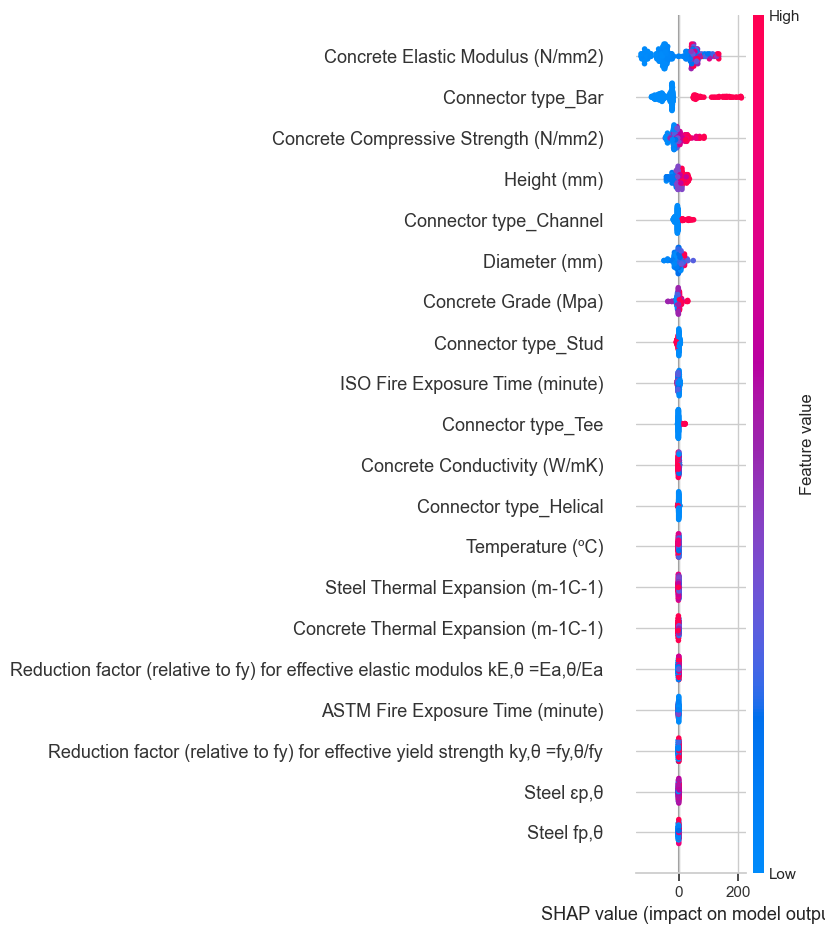

SHAP Summary for Slip:


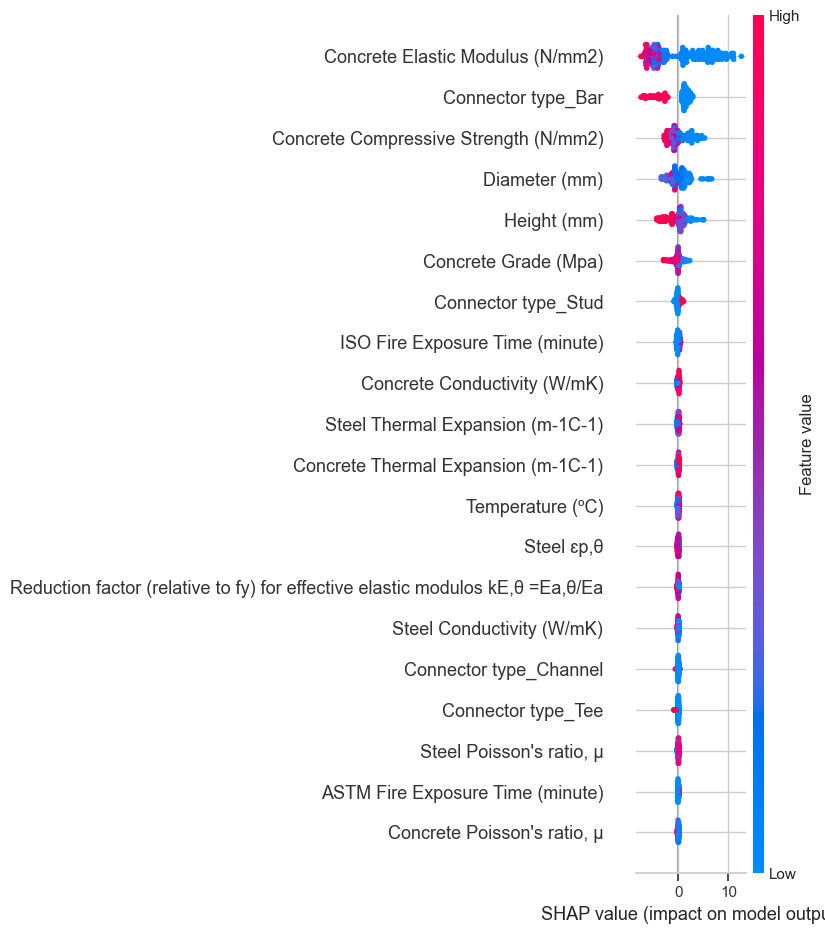

In [6]:
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names = ohe_names + num_cols

# Option 1: Use Multi-Output Random Forest TreeExplainer (Fully Supported by SHAP)
rf_model = fitted_models['RandomForest']
explainer_rf = shap.TreeExplainer(rf_model)
shap_vals_rf = explainer_rf(X_test_trans)

print('SHAP Summary for Ultimate Shear Capacity:')
shap.summary_plot(shap_vals_rf[:, :, 0], X_test_trans, feature_names=feature_names)

print('SHAP Summary for Slip:')
shap.summary_plot(shap_vals_rf[:, :, 1], X_test_trans, feature_names=feature_names)

## 5. Non-Linear Thermo-Structural Load-Slip Curve Generation

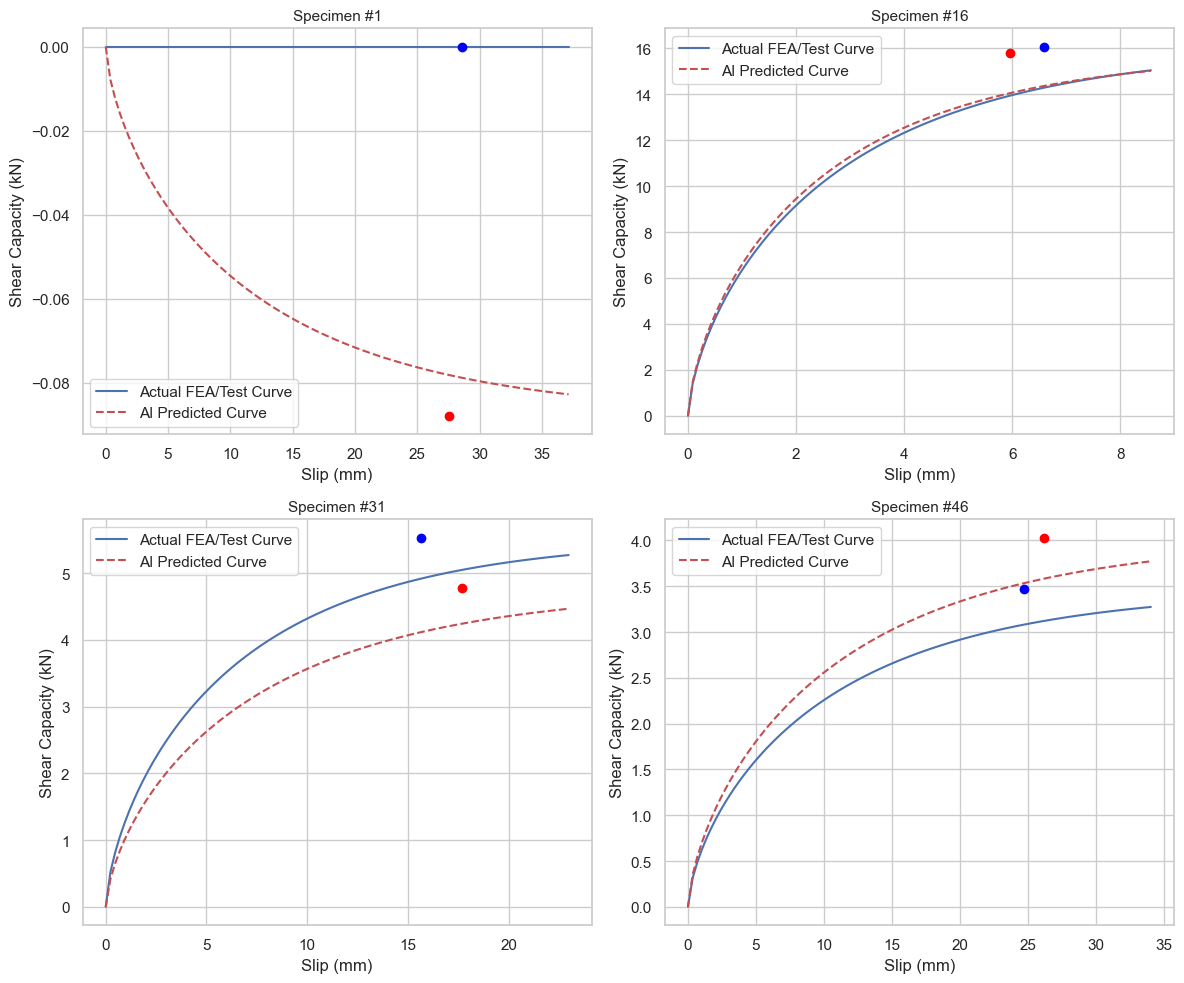

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

indices = [0, 15, 30, 45]
for i, idx in enumerate(indices):
    actual_p, actual_s = y_test.iloc[idx, 0], y_test.iloc[idx, 1]
    pred_p, pred_s = preds[idx, 0], preds[idx, 1]
    
    s_range = np.linspace(0, max(actual_s, pred_s) * 1.3, 100)
    k_act = 1.8 / max(actual_s, 0.1)
    k_pred = 1.8 / max(pred_s, 0.1)
    
    c_act = actual_p * (1.0 - np.exp(-k_act * s_range))**0.65
    c_pred = pred_p * (1.0 - np.exp(-k_pred * s_range))**0.65
    
    axes[i].plot(s_range, c_act, 'b-', label='Actual FEA/Test Curve')
    axes[i].plot(s_range, c_pred, 'r--', label='AI Predicted Curve')
    axes[i].scatter([actual_s], [actual_p], color='blue', zorder=5)
    axes[i].scatter([pred_s], [pred_p], color='red', zorder=5)
    axes[i].set_title(f'Specimen #{idx+1}', fontsize=11)
    axes[i].set_xlabel('Slip (mm)')
    axes[i].set_ylabel('Shear Capacity (kN)')
    axes[i].legend()

plt.tight_layout()
plt.show()